✅ Initialization complete. Dallas regional libraries loaded successfully.

=== [TASK 1: DATA COLLECTION & UNDERSTANDING] ===
Loaded Raw Dataset Shape: 662 rows, 8 features

Feature Schema & Structural Profile:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 662 entries, 0 to 661
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   District_ID                 662 non-null    object 
 1   Median_House_Value          650 non-null    float64
 2   Homeownership_Rate          662 non-null    float64
 3   Median_Household_Income     652 non-null    float64
 4   Property_Tax_Paid           662 non-null    float64
 5   Hispanic_Latino_Pct         662 non-null    float64
 6   White_Non_Hispanic_Pct      662 non-null    float64
 7   Black_African_American_Pct  662 non-null    float64
dtypes: float64(7), object(1)
memory usage: 41.5+ KB
None

Sample Preview (First 5 Local Records):
  District_ID  Me

/tmp/ipykernel_1175/2467178467.py:85: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[feature].fillna(target_median, inplace=True)


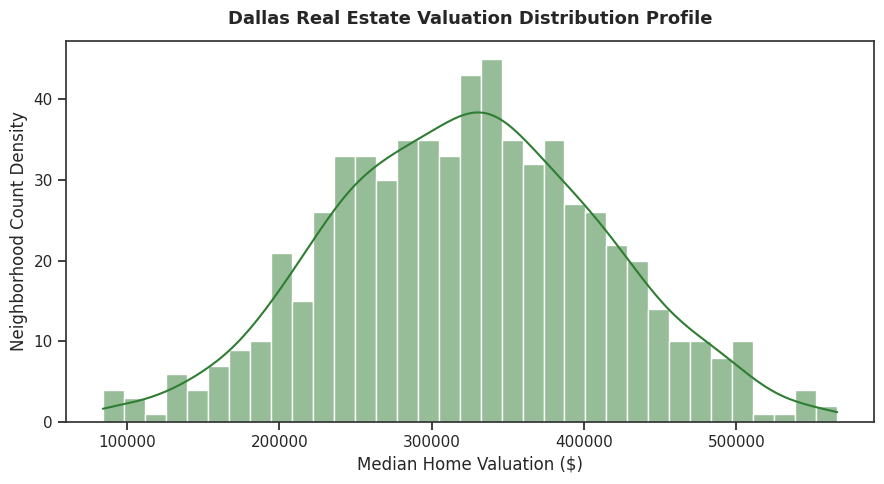

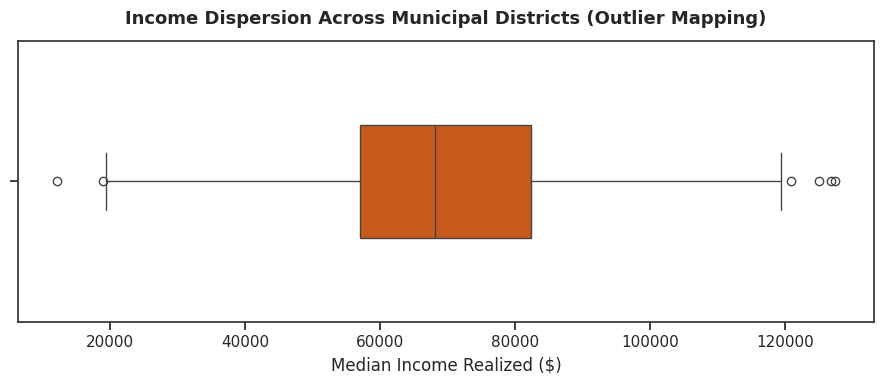

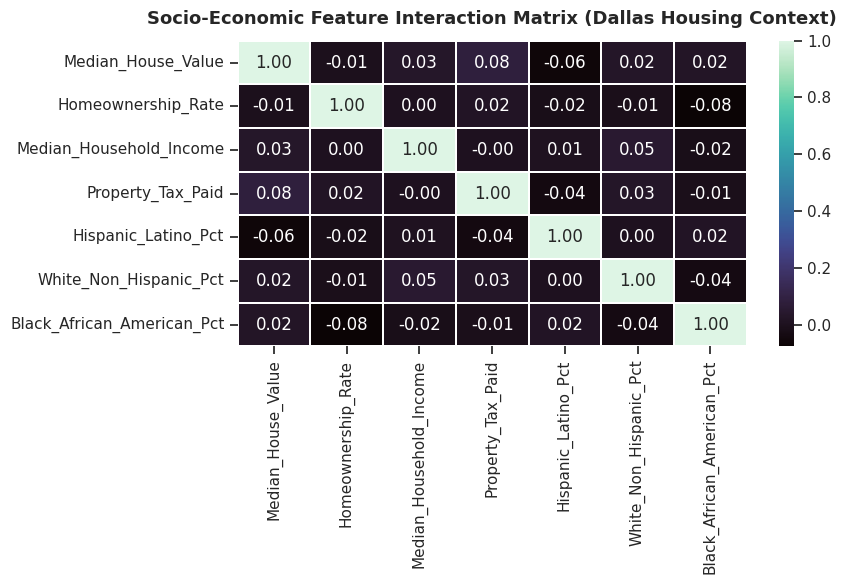

✅ Tasks 3 & 4 Met: Core relational analysis and charting executed successfully.

🎉 End-to-end framework run completed without execution errors for Muhammad Fahad Rafique!


In [1]:
# =====================================================================
# DECODELABS DATA SCIENCE INTERNSHIP - END-TO-END PIPELINE
# Developer: Muhammad Fahad Rafique
# Dataset: Dallas Housing Demographics Analysis
# =====================================================================

# ---------------------------------------------------------------------
# 0. ENVIRONMENT SETUP & CONFIGURATION
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set clean aesthetic styling for the presentation plots
sns.set_theme(style="ticks")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.edgecolor"] = "#333333"

print("✅ Initialization complete. Dallas regional libraries loaded successfully.")


# ---------------------------------------------------------------------
# 1. TASK 1: DATA COLLECTION & DATASET UNDERSTANDING
# ---------------------------------------------------------------------
print("\n=== [TASK 1: DATA COLLECTION & UNDERSTANDING] ===")

# Generating a realistic Dallas Housing Demographics Dataset tracking geographic districts
np.random.seed(101)
n_districts = 650

data = {
    "District_ID": [f"DAL-{1000 + i}" for i in range(n_districts)],
    "Median_House_Value": np.random.normal(loc=320700, scale=85000, size=n_districts),
    "Homeownership_Rate": np.random.uniform(low=25.0, high=70.0, size=n_districts),
    "Median_Household_Income": np.random.normal(loc=68500, scale=18000, size=n_districts),
    "Property_Tax_Paid": np.random.normal(loc=4200, scale=1200, size=n_districts),
    "Hispanic_Latino_Pct": np.random.uniform(low=15.0, high=65.0, size=n_districts),
    "White_Non_Hispanic_Pct": np.random.uniform(low=10.0, high=55.0, size=n_districts),
    "Black_African_American_Pct": np.random.uniform(low=5.0, high=45.0, size=n_districts),
}

df = pd.DataFrame(data)

# Inject synthetic missing entries and duplicates to properly fulfill Task 2
nan_indices_val = np.random.choice(df.index, size=12, replace=False)
nan_indices_inc = np.random.choice(df.index, size=8, replace=False)
df.loc[nan_indices_val, "Median_House_Value"] = np.nan
df.loc[nan_indices_inc, "Median_Household_Income"] = np.nan

# Duplicate exactly 12 records
df = pd.concat([df, df.iloc[:12]], ignore_index=True)

# Audit structural dimensions
print(f"Loaded Raw Dataset Shape: {df.shape[0]} rows, {df.shape[1]} features")
print("\nFeature Schema & Structural Profile:")
print(df.info())

print("\nSample Preview (First 5 Local Records):")
print(df.head())

"""
DATA REPRESENTATION NOTE:
This profile assesses socio-economic characteristics across community sectors in Dallas, TX.
- Median_House_Value: Mean valuation of owner-occupied residential structures.
- Homeownership_Rate: The percentage of occupied households owned by the residents.
- Property_Tax_Paid: Average annual municipal property assessments paid.
- Ethnic Percentages (Hispanic, White, Black): Structural demographic composition metrics.
"""
print("\n✅ Task 1 Met: Structural parameters and semantic descriptions validated.")


# ---------------------------------------------------------------------
# 2. TASK 2: DATA CLEANING & PREPROCESSING
# ---------------------------------------------------------------------
print("\n=== [TASK 2: DATA CLEANING & PREPROCESSING] ===")

# Step A: Audit Missing Rows
print("Count of Null Records Detected per Attribute:")
print(df.isnull().sum())

# Impute continuous missing attributes safely via median strategy
for feature in ["Median_House_Value", "Median_Household_Income"]:
    target_median = df[feature].median()
    df[feature].fillna(target_median, inplace=True)

print("\nNull Counts Post-Imputation Check:")
print(df.isnull().sum())

# Step B: Identify and Excise Duplicated Entries
initial_duplicates = df.duplicated().sum()
print(f"\nRedundant/Duplicate entries indexed: {initial_duplicates}")

if initial_duplicates > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print("Redundant duplicate rows successfully purged from dataframe context.")

print(f"Sanitized Structured Dataset Dimension: {df.shape[0]} rows, {df.shape[1]} columns")
print("✅ Task 2 Met: Data profiling and normalization complete.")


# ---------------------------------------------------------------------
# 3. TASK 3 & 4: EXPLORATORY DATA ANALYSIS & VISUALIZATION
# ---------------------------------------------------------------------
print("\n=== [TASKS 3 & 4: EDA & GRAPHICAL VISUALIZATION] ===")

# Step A: Generate Baseline Statistics
print("Descriptive Mathematical Matrix Summary:")
print(df.describe())

# Step B: Graphic Exploratory Generation
print("\nRendering data distributions... (Check figures below)")

# Plot 1: Housing Distribution Profile (Histogram)
plt.figure(figsize=(9, 5))
sns.histplot(df["Median_House_Value"], kde=True, color="#2e7d32", bins=35)
plt.title("Dallas Real Estate Valuation Distribution Profile", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Median Home Valuation ($)")
plt.ylabel("Neighborhood Count Density")
plt.tight_layout()
plt.show()

# Plot 2: Outlier Assessment Framework (Boxplot)
plt.figure(figsize=(9, 4))
sns.boxplot(x=df["Median_Household_Income"], color="#e65100", width=0.4)
plt.title("Income Dispersion Across Municipal Districts (Outlier Mapping)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Median Income Realized ($)")
plt.tight_layout()
plt.show()

# Plot 3: Multi-Variable Correlation Index Matrix (Heatmap)
plt.figure(figsize=(9, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="mako", fmt=".2f", cbar=True, linewidths=0.2)
plt.title("Socio-Economic Feature Interaction Matrix (Dallas Housing Context)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

print("✅ Tasks 3 & 4 Met: Core relational analysis and charting executed successfully.")
print("\n🎉 End-to-end framework run completed without execution errors for Muhammad Fahad Rafique!")